# Test Code for JASPER

In [1]:
from pyJASPER import JASPER
import numpy as np
import matplotlib.pyplot as plt

## A toy spatial transcriptomics dataset

In [2]:
np.random.seed(1)

# Dimensions
n = 2000            # number of spots
p = 500             # number of genes
p_spatial = p // 5  # 20% of genes are spatial
K = 10              # number of spatial basis functions
r = 10              # latent factor dimension

# Spatial coordinates
coords = np.random.uniform(0, 1, size=(n, 2))
x = coords[:, 0]
y = coords[:, 1]

# True spatial basis matrix X: Polynomial + smooth nonlinear basis
X_true = np.column_stack([
    np.ones(n),
    x,
    y,
    x**2,
    y**2,
    x * y,
    np.sin(2 * np.pi * x),
    np.sin(2 * np.pi * y),
    np.cos(2 * np.pi * x),
    np.cos(2 * np.pi * y),
])

# Library sizes
N = np.random.poisson(5000, size=n).astype(float)

# True SVG indicators
true_gamma = np.zeros(p, dtype=int)
true_gamma[:p_spatial] = 1

# True spatial coefficients
B_true = np.zeros((K, p))
for j in range(p):
    if true_gamma[j] == 1:
        B_true[:, j] = np.random.normal(0, 0.5, size=K)

# Gene specific intercepts
alpha_true = np.random.normal(-4.0, 0.3, size=p)

# Low-rank factor structure
F_true = np.random.normal(0, 1, size=(n, r))
Lambda_true = np.random.normal(0, 0.4, size=(p, r))

# Residual variances
psi_true = np.random.gamma(shape=2.0, scale=0.1, size=p)

# Latent Gaussian expressions
spatial_part = X_true @ B_true
factor_part = F_true @ Lambda_true.T
noise = np.random.normal(
    0,
    np.sqrt(psi_true)[None, :],
    size=(n, p),
)
Y = (
    alpha_true[None, :]
    + spatial_part
    + factor_part
    + noise
)

# NB count data generation
phi_true = np.random.gamma(shape=10.0, scale=2.0, size=p)   # NB dispersions
mu_true = N[:, None] * np.exp(Y)                                 # NB means

C = np.zeros((n, p), dtype=int)
for j in range(p):
    prob = phi_true[j] / (phi_true[j] + mu_true[:, j])

    C[:, j] = np.random.negative_binomial(
        phi_true[j],
        prob,
        size=n,
    )

# Toy data generation statistics
print("Count matrix shape:", C.shape)
print("Spatial basis shape:", X_true.shape)
print("True spatial genes:", np.where(true_gamma == 1)[0])

Count matrix shape: (2000, 500)
Spatial basis shape: (2000, 10)
True spatial genes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


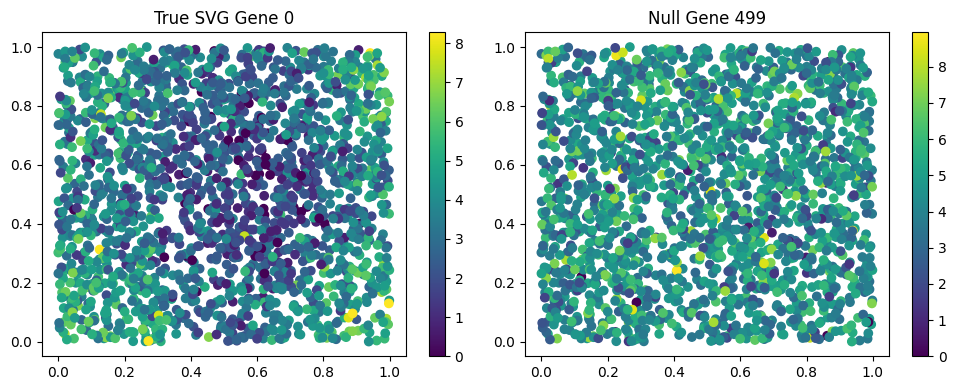

In [3]:
# Visualizing a true SVG and a null gene

gene_svg = 0
gene_null = p - 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sc1 = axes[0].scatter(
    x,
    y,
    c=np.log1p(C[:, gene_svg]),
)

axes[0].set_title(f"True SVG Gene {gene_svg}")

plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(
    x,
    y,
    c=np.log1p(C[:, gene_null]),
)

axes[1].set_title(f"Null Gene {gene_null}")

plt.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()

## Fitting JASPER model

In [4]:
# Initializing a JASPER object
sampler = JASPER(
    C=C,
    X=X_true,
    N=N,
    r=3,
    n_iter=400,
    burn=200,
    thin=2,
    a_phi=2.0,
    b_phi=0.1,
    phi_proposal_sd=0.10,
    seed=123,
)

# Fitting JASPER using MCMC
sampler.run(verbose=True, show_every=10)

iter    10/400 | active= 99 | mean(phi)=12.339 | mean(psi)=1.233 | g=122.142
iter    20/400 | active= 99 | mean(phi)=12.735 | mean(psi)=1.214 | g=125.236
iter    30/400 | active= 99 | mean(phi)=12.829 | mean(psi)=1.212 | g=122.385
iter    40/400 | active= 99 | mean(phi)=12.866 | mean(psi)=1.215 | g=119.986
iter    50/400 | active= 99 | mean(phi)=12.958 | mean(psi)=1.211 | g=121.311
iter    60/400 | active= 99 | mean(phi)=12.901 | mean(psi)=1.205 | g=109.613
iter    70/400 | active= 99 | mean(phi)=12.847 | mean(psi)=1.208 | g=120.587
iter    80/400 | active= 99 | mean(phi)=12.757 | mean(psi)=1.202 | g=137.839
iter    90/400 | active= 99 | mean(phi)=12.730 | mean(psi)=1.203 | g=124.168
iter   100/400 | active= 99 | mean(phi)=12.646 | mean(psi)=1.205 | g=125.800
iter   110/400 | active= 99 | mean(phi)=12.643 | mean(psi)=1.197 | g=123.028
iter   120/400 | active= 99 | mean(phi)=12.508 | mean(psi)=1.203 | g=122.956
iter   130/400 | active= 99 | mean(phi)=12.462 | mean(psi)=1.199 | g=127.516

## Posterior summaries

In [5]:
# Calculating metrics and SVG selection
ppi = sampler.posterior_inclusion_probabilities()

selected_05 = sampler.selected_genes_by_threshold(0.5)

selected_pefdr, threshold = sampler.selected_genes_by_pefdr(target=0.05)

phi_hat = sampler.posterior_phi_mean()

psi_hat = sampler.posterior_psi_mean()

# Printing results
print("\n====================================")
print("True spatial genes:")
print(np.where(true_gamma == 1)[0])

print("\nPosterior inclusion probabilities:")
print(np.round(ppi, 3))

print("\nSelected genes (PPI >= 0.5):")
print(selected_05)

print("\nSelected genes (peFDR):")
print(selected_pefdr)

print("\npeFDR threshold:")
print(np.round(threshold, 3))

print("\nPosterior mean phi:")
print(np.round(phi_hat, 3))

print("\nPosterior mean psi:")
print(np.round(psi_hat, 3))

print("\nPhi acceptance rates:")
print(np.round(sampler.phi_accept_rate, 3))


True spatial genes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]

Posterior inclusion probabilities:
[1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   0.01 1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   

## Visualizing fitted JASPER model: Plot of PPIs

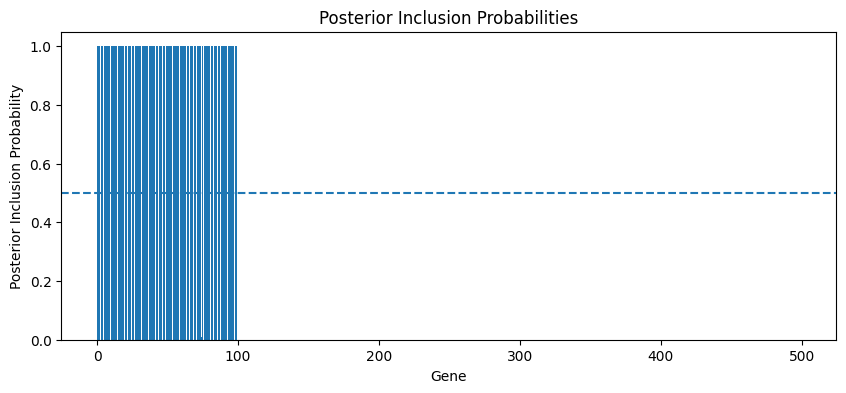

In [6]:
plt.figure(figsize=(10, 4))

plt.bar(np.arange(p), ppi)

plt.axhline(
    0.5,
    linestyle="--",
)

plt.xlabel("Gene")
plt.ylabel("Posterior Inclusion Probability")
plt.title("Posterior Inclusion Probabilities")

plt.show()